# Homework 6: N-Gram Language Models with the Brown Corpus

In this assignment you’ll practice **probabilistic language modeling (PLM)** by building N-gram models that generate text. Along the way, you’ll develop the core components of a language model: estimating conditional probabilities, calculating sentence likelihoods, and generating text using principled probabilistic strategies. The goal is to understand *how simple statistical models can produce coherent language*, and how careful choices in scoring and decoding affect the quality of generated text.


### Learning Objectives

* Build and compare **bigram and trigram** language models.
* Calculate **word and sentence probabilities** in log space and use them to compute **perplexity**.
* Implement **probability-based generation** methods, including temperature-scaled sampling.
* Explore **beam search** as a structured alternative to greedy generation.


### **The four problems (high level)**

1. **Problem 1 — N-gram probabilities (bigrams & trigrams):**
   Build bigram and trigram count models from the corpus and convert next-word probabilities into **log space** to avoid numerical underflow.

2. **Problem 2 — Controlled sentence generation:**
   Generate sentences using trigram contexts when available, **backing off to bigrams** as needed, and explore how **temperature** controls randomness in the generated text.

3. **Problem 3 — Sentence probability & perplexity:**
   Define sentence probability in log space, normalize for sentence length using **average log probability (ALP)**, and compute **perplexity** as a measure of model quality.

4. **Problem 4 — Beam search:**
   Implement **beam search**, ranking partial candidates by ALP during generation, then compare completed sentences using **perplexity** and contrast the results with greedy decoding.


By the end, you’ll have a working N-Gram generator capable of producing reasonable sentences, and a solid understanding of how early probabilistic approaches to NLP laid the foundation for modern deep learning methods.



### Recommended PROTOTYPING Workflow (Must Read!)

One of the most important skills in machine learning is following a **disciplined prototyping workflow** when developing complex code. The basic idea, is simple:

1. **Start small:** Write and test your code using a tiny subset of your dataset.
2. **Inspect your results:** Print out and examine intermediate outputs to verify that each step behaves as expected.
3. **Iterate and tune:** Adjust hyperparameters and continue testing, gradually increasing the subset size as needed.
4. **Scale up:** Once you are confident your code is bug-free and your hyperparameters are roughly correct, run it on the **full dataset** to obtain your final results.

If you don’t have sufficient computing resources for a full run, use **as large a subset as practical** — provided you’ve begun early enough to allow for multiple iterations.


To help you follow this workflow in this homework, I’ve included a variable `num_sentences` that controls how many sentences are used from the shuffled Brown Corpus.

I recommend the following progression:

* **Step 1:** Begin with `num_sentences = 10` to debug and print out intermediate data structures (such as dictionaries) to confirm that your code works as expected.
* **Step 2:** Increase to `num_sentences = 100` to verify correctness and complete most of the homework efficiently.
* **Step 3:** Finally, if possible, run with the full dataset (`num_sentences = 57_340`), or as large a subset as your resources allow, to answer the graded questions.


There are 9 problems in this homework, each worth 9 points each, and you get 4 points free if you otherwise complete the homework.

#### Useful Imports (add more as needed)

In [1]:
import math
import re
import string
import random
import spacy
import numpy as np
import pandas as pd
from tqdm import tqdm
from matplotlib import pyplot as plt
from collections import Counter

random.seed(42)

#### Utility Function to Pretty-Print Sentences

In [2]:
'''
Reconstruct a human-readable sentence from tokens.
- Capitalize the first token (after removing <s>).
- Attach any token in string.punctuation with no preceding space.
- Attach tokens starting with an apostrophe (e.g., "'s", "'ll") with no space.
- Capitalize standalone 'i' and 'god' wherever they appear.
- If the last token is '.', '?', or '!', attach it without a space.
- Ignore boundary markers <s> and </s> if present.
Returns the sentence string and also prints it depending on flag parameter.
'''

def print_sentence(tokens, do_print=True):

    if not tokens:
        print("")
        return ""

    # Drop boundary markers if present
    start = 1 if tokens and tokens[0] == "<s>" else 0
    end = -1 if tokens and tokens[-1] == "</s>" else len(tokens)
    core = tokens[start:end]

    if not core:
        print("")
        return ""

    # Capitalize first token
    out = core[0].capitalize()

    # Process remaining tokens with spacing rules
    for i, t in enumerate(core[1:], start=1):
        is_last = (i == len(core) - 1)

        # Last-token punctuation rule
        if is_last and t in {".", "?", "!"}:
            out += t
            continue

        # General punctuation attaches with no space (e.g., ',', ':', ';', ')', etc.)
        if t in string.punctuation:
            out += t
            continue

        # Apostrophe-start tokens like "'s", "'d", "'ll"
        if t.startswith("'"):
            out += t
            continue

        # Capitalize special standalone words
        if t.lower() in {"i", "god"}:
            out += " " + t.capitalize()
            continue

        # Default: add a space before normal words
        out += " " + t

    if do_print:
        print(out)
    return out


### Read in the list of all sentences in the Brown Corpus and process using SPaCy.

In [3]:
# Must do this the first time to get the Natural Language ToolKit

!pip install nltk

In [48]:
import nltk
from nltk.corpus import brown
import spacy

nltk.download('brown')

# Get all Brown corpus sentences as raw text
# Brown is organized into categories, we flatten it into one list of sentences and shuffle
# so we can create a shorter list for testing

brown_texts = [" ".join(sent) for sent in brown.sents()]

random.shuffle(brown_texts)

# Brown has 57_340 sentences, set `num_sentences` to 1000 or smaller for testing

# num_sentences = 57_340
num_sentences = 57_340                           # <<<<<=====    Here is where you can change the size of the dataset

brown_texts = brown_texts[:num_sentences]

# Load spaCy English pipeline
nlp = spacy.load("en_core_web_sm")

# Process with spaCy: tokenize + sentencize
docs = list(nlp.pipe(brown_texts, disable=["ner", "tagger", "parser"]))

# Each doc is one sentence; extract tokens and add beginning and ending tokens <s> ... </s>
tokenized_sentences = [ ['<s>'] + [token.text.lower() for token in doc if not token.is_space] + ['</s>'] for doc in docs ]

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


#### If you have trouble downloading this...


I have uploaded a file `brown_sentences.txt` to a Google Drive folder which anyone with the link can read, just
uncomment the code in the next cell and run it:

In [49]:

import re, requests, random, spacy

# Paste the shared Drive link (no need to change anything else)
link = "https://drive.google.com/file/d/1f_BkNDF0ny11Tn4D4jsOoXhgPSUCHKlf/view?usp=drive_link"

# --- Convert to direct download URL ---
def get_direct_download_url(link):
    match = re.search(r"/d/([a-zA-Z0-9_-]+)", link) or re.search(r"id=([a-zA-Z0-9_-]+)", link)
    if not match:
        raise ValueError("Could not extract file ID from the link.")
    file_id = match.group(1)
    return f"https://drive.google.com/uc?export=download&id={file_id}"

url = get_direct_download_url(link)

# --- Download and prepare the text ---
response = requests.get(url)
lines = response.text.strip().split("\n")

random.shuffle(lines)


# Etc as before


In [50]:
print("Number of sentences:", len(tokenized_sentences))
print("First sentence:      ",end='')
print_sentence(tokenized_sentences[0])
print("Tokenized sentence: ",end='')
print(tokenized_sentences[0])

Number of sentences: 57340
First sentence:      The name fell with lazy affectionate remembrance from her lips.
Tokenized sentence: ['<s>', 'the', 'name', 'fell', 'with', 'lazy', 'affectionate', 'remembrance', 'from', 'her', 'lips', '.', '</s>']


### A Little EDA....

In [51]:
# Flatten tokens (exclude spaces)
all_tokens = [tok.text.lower() for sent in docs for tok in sent if not tok.is_space]

# Define "word": alphabetic, or alphabetic after removing internal apostrophes
def is_word(tok):
    s = tok.text
    return s.isalpha() or s.replace("'", "").isalpha()

# Extract words using the definition above
words = [
    tok.text.lower()
    for sent in docs
    for tok in sent
    if not tok.is_space and is_word(tok)
]

# Counts
num_chars = sum(len(s) for s in brown_texts)   # or len(text) if you started from one big text
num_tokens = len(all_tokens)
num_unique_tokens = len(set(all_tokens))
num_sentences = len(docs)
num_words = len(words)
num_unique_words = len(set(words))

print(f"Total number of characters in the text: {num_chars:,}")
print(f"Total number of tokens:    {num_tokens:,}")
print(f"Number of unique tokens:   {num_unique_tokens:,}")
print(f"Total number of sentences: {num_sentences:,}")
print(f"Total number of words:     {num_words:,}")
print(f"Number of unique words:    {num_unique_words:,}")

# Frequencies
word_counts = Counter(words)
most_common_words = word_counts.most_common()

# Top 10
print("\nTop 10 words:")
for token, freq in most_common_words[:10]:
    print(f"{token:<15}: {freq:,}")

# Bottom 10
print("\nBottom 10 words:")
for token, freq in most_common_words[-10:]:
    print(f"{token:<15}: {freq:,}")

Total number of characters in the text: 6,069,734
Total number of tokens:    1,198,833
Number of unique tokens:   43,320
Total number of sentences: 57,340
Total number of words:     1,017,681
Number of unique words:    41,455

Top 10 words:
the            : 70,003
of             : 36,473
and            : 28,916
to             : 26,241
a              : 23,259
in             : 21,419
that           : 10,789
is             : 10,206
was            : 9,969
he             : 9,801

Bottom 10 words:
sallow         : 1
marbleized     : 1
unfalteringly  : 1
dalles         : 1
decertify      : 1
illusionary    : 1
flog           : 1
turandot       : 1
tragically     : 1
parkinson      : 1


### Digression: Zipf's Law

Zipf's Law is an empirical regularity of natural language:  
if you rank words by their frequency in a corpus, the frequency \( f(r) \) of the word at rank \( r \) is approximately inversely proportional to its rank:

$$
f(r) \propto \frac{1}{r^k}
$$

where $ r = 1, 2, 3, \dots $ is the rank of a word (1 = most frequent), and $ k \approx 1 $.  

- The most common words (e.g., *the*, *of*, *and*) occur very often.  
- A handful of mid-ranked words occur moderately often.  
- The vast majority of words occur rarely.  

On a **log–log plot** of frequency vs. rank, this relationship appears as a straight line with slope \(-k\).  
For natural language, empirical studies show that $k \approx 1$, which is why we plot below a reference line with slope $-1$ to compare against real corpus data.


**Why this matters:** Because most words are rare, language models must use techniques like **smoothing, subword modeling, or embeddings** to handle sparsity and represent meaning effectively.  


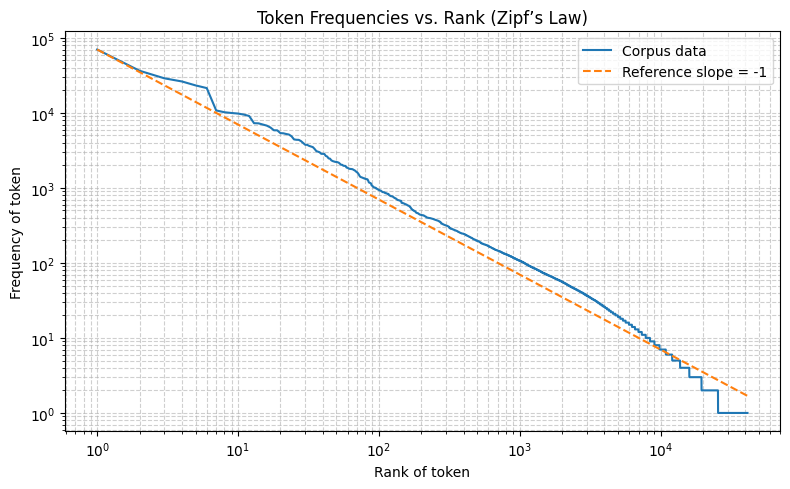

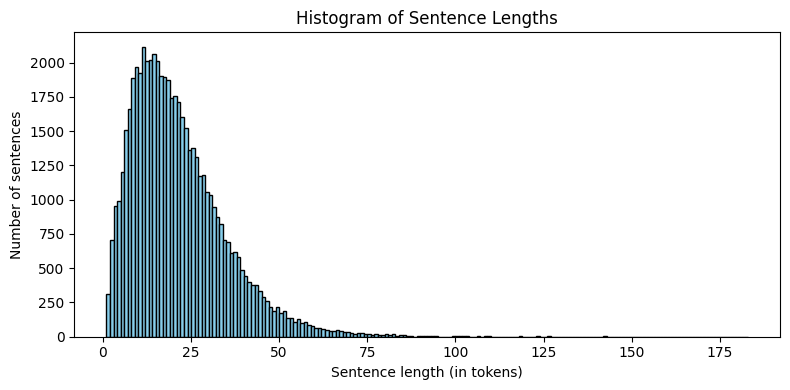

Average sentence length: 20.91 tokens
Max sentence length:     182 tokens


In [52]:
# Frequencies sorted by rank
freqs = np.array([freq for token, freq in word_counts.most_common()])
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(8, 5))
plt.plot(ranks, freqs, label="Corpus data")

# Reference line: slope = -1 (Zipf’s law)
# Match scale by anchoring at the first frequency
ref_line = freqs[0] / ranks
plt.plot(ranks, ref_line, "--", label="Reference slope = -1")

plt.xscale("log")
plt.yscale("log")
plt.title("Token Frequencies vs. Rank (Zipf’s Law)")
plt.xlabel("Rank of token")
plt.ylabel("Frequency of token")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Compute sentence lengths from spaCy docs
sentence_lengths = [len([tok for tok in sent if not tok.is_space]) for sent in docs]

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(
    sentence_lengths,
    bins=range(1, max(sentence_lengths) + 2),
    color="skyblue",
    edgecolor="black"
)
plt.title("Histogram of Sentence Lengths")
plt.xlabel("Sentence length (in tokens)")
plt.ylabel("Number of sentences")
plt.tight_layout()
plt.show()

print(f"Average sentence length: {sum(sentence_lengths)/len(sentence_lengths):.2f} tokens")
print(f"Max sentence length:     {max(sentence_lengths)} tokens")

## Problem One — Build the PLM (bigrams & trigrams)

For this problem, you must adapt (mostly cut-and-paste) the code from this week’s Coding Notebook to the new dataset. You are using a trigram model as well as bigrams but your professor has written code that should mostly work for any N.

We provide a pre-processed dataset above, with sentences already tokenized and enclosed in the boundary tokens `<s>` and `</s>`.

**Set `num_sentences=10` to start!**

**ToDo:**

**A.** Build N-grams for N = 2, 3

- Compute all bigrams and trigrams over the tokenized sentences (boundary tokens included).

**B.** Create a dictionary mapping left-contexts to next-word lists

- For each N, map each context (length N−1) to a list of next tokens (allow duplicates so frequency = count).

**C.** Convert to (log) probability distributions

- Turn each context’s next-word list into a distribution of log-probabilities (see **Appendix Two**).

**D.** Create the Probability Language Model (PLM)

- Create a dictionary `get_next_word` with:

    - Key: left context (tuple of 1 token for bigrams; 2 tokens for trigrams).
    
    - Values: nested dictionary mapping next tokens to log-probabilities `{next_token: log_prob, ...}`.

- Create a **single dictionary** (since bigrams and trigrams have a left context of different lengths, and they won't get confused in the dictionary).


**E.** Set the variable `num_sentences = 10` and do a sanity check by displaying the distribution for the bigram contexts e.g., `('<s>',)` and `('the',)` and a trigram context `('<s>','the')`. If for some reason these are not present, increase the number of sentences slightly.  

**F.**  Generate 5 next words for each of the 3 examples in the previous part.

**Then answer the graded questions.**

In [53]:
# Your code here (add as many cells as you need)
data = tokenized_sentences[:num_sentences]
## A. Build N-grams

def build_ngrams(sentences, N):
    ngrams = []
    for sent in sentences:
        for i in range(len(sent) - N + 1):
            ngrams.append(tuple(sent[i:i+N]))
    return ngrams

In [54]:
## B. Create a dictionary mapping left-contexts to next-word lists
from collections import defaultdict, Counter

def context_to_nextword_list(ngrams, N):
    mapping = defaultdict(list)
    for ng in ngrams:
        context = ng[:-1]
        nxt = ng[-1]
        mapping[context].append(nxt)
    return mapping

In [55]:
## C. Convert to Probability Distributions

def nextword_list_to_logprobs(next_words):
    counts = Counter(next_words)
    total = sum(counts.values())
    logprob = {w: math.log(c / total) for w, c in counts.items()}
    return logprob


def make_logprob_distributions(context_map):
    dist = {}
    for ctx, nxt_list in context_map.items():
        dist[ctx] = nextword_list_to_logprobs(nxt_list)
    return dist

In [56]:
## D. Create the PLM

def build_plm(sentences, Ns=(2, 3)):
    get_next_word = {}
    for N in Ns:
        ngrams = build_ngrams(sentences, N)                      # A
        ctx_map = context_to_nextword_list(ngrams, N)            # B
        ctx_dist = make_logprob_distributions(ctx_map)           # C
        # Merge into one dictionary
        get_next_word.update(ctx_dist)                           # D
    return get_next_word


get_next_word = build_plm(data, Ns=(2, 3))


In [57]:
def show_context(get_next_word, context, top_k=15):
    if context not in get_next_word:
        print(f"{context} NOT FOUND (try increasing num_sentences)")
        return
    dist = get_next_word[context]
    # sort by probability descending (log_prob descending is same ordering)
    items = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:top_k]
    print(f"\nContext: {context}")
    for w, lp in items:
        print(f"  {w:>10}  logP={lp:.4f}  P={math.exp(lp):.4f}")

In [58]:
## E. Sanity Check

# Bigram contexts are length-1 tuples: ('<s>',) and ('the',)
# Trigram context is length-2 tuple: ('<s>','the')
show_context(get_next_word, ("<s>",))
show_context(get_next_word, ("the",))
show_context(get_next_word, ("<s>", "the"))


Context: ('<s>',)
         the  logP=-2.1237  P=0.1196
           `  logP=-2.6216  P=0.0727
          he  logP=-2.9325  P=0.0533
          it  logP=-3.2859  P=0.0374
          in  logP=-3.4888  P=0.0305
           i  logP=-3.6257  P=0.0266
         but  logP=-3.6941  P=0.0249
        this  logP=-3.9215  P=0.0198
           a  logP=-3.9241  P=0.0198
         and  logP=-3.9250  P=0.0197
         she  logP=-4.1066  P=0.0165
        they  logP=-4.1226  P=0.0162
       there  logP=-4.1768  P=0.0153
          if  logP=-4.4128  P=0.0121
          we  logP=-4.5238  P=0.0108

Context: ('the',)
       first  logP=-4.6550  P=0.0095
        same  logP=-4.7138  P=0.0090
        most  logP=-5.1208  P=0.0060
       other  logP=-5.1232  P=0.0060
           `  logP=-5.1524  P=0.0058
         new  logP=-5.1673  P=0.0057
       world  logP=-5.1698  P=0.0057
      united  logP=-5.1825  P=0.0056
       state  logP=-5.4727  P=0.0042
         two  logP=-5.5287  P=0.0040
        only  logP=-5.6033  P=0.0037


In [59]:
## F. Generate 5 next words
def sample_next_token(dist_dict):
    """
    dist_dict: {token: log_prob}
    Returns one sampled token according to the probabilities.
    """
    tokens = list(dist_dict.keys())
    logps = np.array([dist_dict[t] for t in tokens], dtype=float)

    # stable softmax from log-probs
    m = logps.max()
    probs = np.exp(logps - m)
    probs = probs / probs.sum()

    return np.random.choice(tokens, p=probs)


def generate_next_words(get_next_word, context, k=5, seed=0):
    """
    Generates k samples of the next word from the context distribution.
    This is NOT full sentence generation—just 'next token' sampling k times.
    """
    np.random.seed(seed)
    if context not in get_next_word:
        return [f"[context {context} not found]"]
    dist = get_next_word[context]
    return [sample_next_token(dist) for _ in range(k)]


contexts_to_test = [
    ("<s>",),          # bigram context
    ("the",),          # bigram context
    ("<s>", "the")     # trigram context
]

for ctx in contexts_to_test:
    samples = generate_next_words(get_next_word, ctx, k=5, seed=1)
    print(f"\n5 sampled next-words for {ctx}: {samples}")


5 sampled next-words for ('<s>',): [np.str_('but'), np.str_('one'), np.str_('the'), np.str_('he'), np.str_('`')]

5 sampled next-words for ('the',): [np.str_('public'), np.str_('register'), np.str_('name'), np.str_('artist'), np.str_('administration')]

5 sampled next-words for ('<s>', 'the'): [np.str_('war'), np.str_('guards'), np.str_('name'), np.str_('latter'), np.str_('future')]


### Graded Question:

In the next cell, set `a1` to the list of 5 next words for the trigram context `('<s>','the')` (unlikely, but you may have to adjust `num_sentences` as indicated).

In [60]:
# Your answer here

a1 = [str(w) for w in generate_next_words(get_next_word, ("<s>", "the"), k=5, seed=1)]

In [61]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem

print(f'a1 = {a1}')


a1 = ['war', 'guards', 'name', 'latter', 'future']


## Problem Two: Generating Sentences with Backoff and Temperature

The basic algorithm for generating sentences from an N-Gram probabilistic language model (PLM) is straightforward: at each step, look at the most recent tokens of the sentence, use the corresponding conditional probability distribution to select the next word, and continue until the end-of-sentence token `</s>` is generated.

For **bigrams**, this process is reliable. Every token has a valid continuation because each sentence is explicitly terminated with `</s>`.

For **higher-order N-grams** ($N>2$), however, two important complications arise.


### 1. Cold start (insufficient left context)

At the beginning of a sentence, there are not yet enough tokens to form a full $(N-1)$-token context. In this case, you must generate words using whatever left context is currently available.

For example, when using **trigrams**:

                                          Find next word using:
        Step 1:    <s> ?                      bigrams
         context:  ---
        Step 2:    <s> One ?                  trigrams
         context:  -------
        Step 3:    <s> One fish ?             continue on with trigrams
         context:  ------------


Until enough tokens are present, generation proceeds using lower-order N-grams.


### 2. Sparsity (missing N-grams)

Even after sufficient context is available, it is possible that **no N-gram exists** for a particular left context.

For example, suppose the sentence so far is:


    One fish dish ...


If the trigram context `("fish", "dish")` never appears in the training corpus, then the trigram model provides **no valid next-word distribution**.

In this case, you must use a **backoff strategy**:

> If no N-gram exists for the current left context, drop the earliest token and try again using a lower-order N-gram.

Concretely:
- If the trigram context fails, back off to a bigram using the most recent token.
- (In general, for larger N, continue backing off to lower orders as needed.)
- With explicit sentence boundary tokens, a valid bigram context will always exist.



### Backoff decision logic (conceptual)

Your generator should follow this logic at each step:


    if (w_{t-2}, w_{t-1}) exists:
         use trigram distribution
    else if (w_{t-1}) exists:
         use bigram distribution
    else:
         stop or handle gracefully   (when we use a start symbol <s>, this case will never occur)



This logic determines *which probability distribution* is used to sample the next word.



### Temperature-controlled sampling

Once the appropriate distribution is selected, you will apply **temperature scaling** before sampling the next word. Lower temperatures concentrate probability mass on high-likelihood words (more conservative output), while higher temperatures flatten the distribution (more diverse but less predictable output).



### To Do

- Adapt the sentence-generation code from the coding video to implement the **backoff strategy** described above, using your probability models from Problem One.
- Remember to **convert log probabilities back into ordinary probabilities** before passing them as weights to  
  `np.random.choice(..., p=weights)`.
- Perform **three experiments**, using temperatures **0.2**, **1.0**, and **5.0** (using the full dataset if possible):
  - Generate **10 sentences** at each temperature.
  - Print each sentence using `print_sentence` and observe qualitative differences in fluency and diversity.
- **Guardrail:** If the end-of-sentence token `</s>` is not generated after **40 tokens**, terminate the sentence generation to prevent runaway output.
- Answer the graded questions.


In [62]:
# Your code here (add as many cells as you need)
## adapting the sentence-generation code w/ temp sampling

def sample_from_logdist_temp(logdist, T=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    tokens = list(logdist.keys())
    logps = np.array([logdist[t] for t in tokens], dtype=float)

    # Apply temperature in log-space: divide log-probs by T
    # (equivalently: raise probs to power 1/T then renormalize)
    scaled = logps / T

    # Convert back to ordinary probabilities (stable)
    m = scaled.max()
    probs = np.exp(scaled - m)
    probs /= probs.sum()

    return rng.choice(tokens, p=probs)

In [85]:
## sentence generator w/ guardrails
def get_sentence_backoff_temp(plm, N=3, T=1.0, max_len=40, seed=None):
    rng = np.random.default_rng(seed)
    sentence = ["<s>"]

    while sentence[-1] != "</s>" and (len(sentence) - 1) < max_len:

        max_ctx_len = N - 1
        used_dist = None

        for ctx_len in range(min(max_ctx_len, len(sentence)), 0, -1):
            ctx = tuple(sentence[-ctx_len:])
            if ctx in plm:
                used_dist = plm[ctx]
                break

        if used_dist is None:
            sentence.append("</s>")
            break

        next_word = sample_from_logdist_temp(used_dist, T=T, rng=rng)
        sentence.append(str(next_word))

    # guardrail without </s>, force stop (terminate)
    if sentence[-1] != "</s>":
        sentence.append("</s>")

    return sentence

In [86]:
def run_temperature_experiments(plm, N=3, temps=(0.2, 1.0, 5.0), num_sentences=num_sentences):
    for T in temps:
        print("\n" + "="*70)
        print(f"TEMPERATURE = {T} | N = {N} | {num_sentences} sentences")
        print("="*70)

        for i in range(num_sentences):
            # Different seed each time for variety but reproducible overall per T
            sent = get_sentence_backoff_temp(plm, N=N, T=T, max_len=40, seed=1000*int(T*10) + i)
            print_sentence(sent)  # your notebook-provided function

run_temperature_experiments(get_next_word, N=3, temps=(0.2, 1.0, 5.0), num_sentences=10)


TEMPERATURE = 0.2 | N = 3 | 10 sentences
The first time in the new york, and the other hand, the`` I'll be a good deal of time.
The first time.
The first time in the next day.
The first time since he was a good deal of pleasure.
The first time in the united states, and the other hand, the first time in the world.
The first time, it is not the only way to the point of view.
The first time in the world.
The first time in the past, and the other hand, the president's staff, and the other hand, the first time in the united states, and the other hand, the other side of the
The first time in the world.
The first two years ago, the first time in the same time, and the other hand, the first time in the world.

TEMPERATURE = 1.0 | N = 3 | 10 sentences
I felt certain it was certain now that is, in volume until it was her father's dinner pail only to qualify as new compounds of the scientists in the next generation.
Instead, he will be lodgment enough.
So it would be an understatement.
These sci

### Graded Questions:

#### Part 2A: In the next cell, set `a2a` to the *most realistic sentence* generated (your call!). Use `print_sentence(..., do_print=False)`.

In [87]:
# Your answer here
best_sent = 'Miss estherson called twice.'
a2a = print_sentence(best_sent, do_print=False)

In [88]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a2a in this problem

print(f'a2a = {a2a}')


a2a = M I s s   e s t h e r s o n   c a l l e d   t w I c e.


#### Part 2B:  Describe in a few sentences what you observed with the different temperature settings (and try more if you wish!). Which seemed to produce the most realistic sentences?

Your answer here:

The most realistic sentences came from the lower temperatures which is to be expected. With the high temperature of 5, the sentences got quite out of hand and made no gramatical sense. Not using the full dataset, generated quite different outcomes where the lower temperatures were very repetitive and the temperature of 5 had provided the most realistic sentence.



## Problem Three: Measuring the Quality of Sentences: Average Log Probability and Perplexity

The probabilities involved when we calculate the probability of longer token sequences are extremely small, and numerical underflow is common for large corpora. Therefore, we calculate all probabilities in **log space** (see **Appendix Two** for an explanation).

At a basic level, the quality metric for generated sentences is **likelihood**: if a sentence is more probable under the model, it is better. However, raw likelihood is biased toward short sentences, since multiplying many probabilities causes long sentences to become extremely unlikely. Natural language does not behave this way!

To remove this length bias, we use the following measures.


### Average Log Probability (ALP)

**Average Log Probability (ALP)** is a length-agnostic measure of sentence probability. For trigrams:

Let the tokenized sentence be $[t_1, \ldots, t_n]$ with $t_1 = \texttt{<s>}$ and $t_n = \texttt{</s>}$.

$$
\text{ALP}([t_1, t_2, \dots, t_n])
\ =\ \frac{\log P(t_2 \mid t_1) + \log P(t_3 \mid t_1, t_2) + \dots + \log P(t_n \mid t_{n-2}, t_{n-1})}{n-1}
$$

**Notes:**
- We do not include the first token because it is always present and is not predicted; think of it as a prompt that starts the sentence.
- To account for backoff, simply use the log probability of the **bigram** when a trigram context is unavailable.
- ALP lies in $(-\infty, 0.0]$, and **larger values are better**. It becomes more negative as the model performs worse.
- We divide by $n-1$ because a sentence with $n$ tokens contains exactly $n-1$ predictions: every token except the initial `<s>` is predicted by the model.



### Perplexity

**Perplexity** is the most commonly used evaluation metric in NLP. It rescales ALP into a more intuitive, positive quantity:

> **Perplexity =** `np.exp(-ALP)`

Perplexities are $\ge 1.0$, and **smaller values are better**. Intuitively, perplexity measures how “confused” the model is: higher perplexity corresponds to choosing among more equally likely alternatives (roughly, a larger effective branching factor).

Because the exponential function is monotonic, minimizing perplexity is exactly equivalent to maximizing ALP. Either metric may be used for ranking models, but perplexity is the standard reporting metric in NLP.

> **Important:** In the remaining problems, **ALP is used internally to compare candidate sentences**, while **perplexity is used to report and compare completed sentences**.



### Before You Start

You can compute ALP during generation by carrying **state** along with the partial sentence.  
Instead of storing:

> `tokens_so_far = ['<s>', t2, t3, …]`

store a **pair**:

> `(tokens_so_far, sum_log_probs)`

where

- **sum_log_probs** $= \log P(t_2 \mid t_1) + \log P(t_3 \mid t_1, t_2) + \cdots$

If backoff was used to generate some token $t_k$, simply use  $\log P(t_k \mid t_{k-1})$ for that step.

Your generation loop should follow this structure:

1. Start with `tokens = ['<s>']` and `sum_log_probs = 0.0`.
2. Determine the left context (prefer trigrams; back off to bigrams if needed).
3. **Sample** the next token using temperature, but **score** it using the model’s true (untempered) log probability:
```

sum_log_probs += log P(next | context)

```
4. Append the token. If it is `</s>`, stop; otherwise, repeat from step 2.
5. After completion:
- Compute `ALP = sum_log_probs / (len(tokens) - 1)`
- Compute `PP = np.exp(-ALP)`
- Return the pair `(completed_tokens, PP)`



### To Do

- Modify your `get_next_word` and sentence generator to maintain `(tokens, sum_log_probs)` and return `(tokens, PP)`.
- Perform **three experiments** with temperature set to **0.2**, **1.0**, and **5.0** (using the full dataset if possible):
- Generate **10 sentences** per temperature.
- Print them using `print_sentence` and compare fluency and diversity with their perplexities.
- Answer the graded questions.


In [89]:
# Your code here: add as many cells as you wish
def softmax_from_logps(logps):
    m = np.max(logps)
    p = np.exp(logps - m)
    return p / p.sum()

def choose_context_backoff(tokens, plm, N):
    max_ctx_len = N - 1
    for ctx_len in range(min(max_ctx_len, len(tokens)), 0, -1):
        ctx = tuple(tokens[-ctx_len:])
        if ctx in plm:
            return ctx, plm[ctx]
    return None, None  # should not happen with <s> and bigrams present

def sample_next_and_score(dist_dict, T=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    tokens = list(dist_dict.keys())
    true_logps = np.array([dist_dict[t] for t in tokens], dtype=float)

    # Sample with temperature: scale logps by 1/T
    scaled_logps = true_logps / T
    probs = softmax_from_logps(scaled_logps)

    idx = rng.choice(len(tokens), p=probs)
    next_tok = tokens[idx]
    true_lp = float(true_logps[idx])  # score with untempered logP

    return str(next_tok), true_lp

In [90]:
def get_sentence_backoff_with_pp(plm, N=3, T=1.0, max_len=40, seed=None):
    rng = np.random.default_rng(seed)

    tokens = ["<s>"]
    sum_log_probs = 0.0

    while tokens[-1] != "</s>" and (len(tokens) - 1) < max_len:
        ctx, dist = choose_context_backoff(tokens, plm, N)

        if dist is None:
            tokens.append("</s>")
            break

        next_tok, true_lp = sample_next_and_score(dist, T=T, rng=rng)

        tokens.append(next_tok)
        sum_log_probs += true_lp

    # Guardrail: if we never generated </s>, terminate
    if tokens[-1] != "</s>":
        tokens.append("</s>")

    alp = sum_log_probs / (len(tokens) - 1)
    pp = float(np.exp(-alp))

    return tokens, pp

In [91]:
def run_problem3_experiments(plm, N=3, temps=(0.2, 1.0, 5.0), num_sentences=num_sentences):
    for T in temps:
        print("\n" + "="*80)
        print(f"T = {T} | N = {N} | {num_sentences} sentences (showing perplexity)")
        print("="*80)

        for i in range(num_sentences):
            sent_tokens, pp = get_sentence_backoff_with_pp(
                plm, N=N, T=T, max_len=40, seed=10000 + int(T*100) + i
            )
            # print sentence + perplexity
            s = print_sentence(sent_tokens, do_print=False)
            print(f"PP={pp:8.2f} | {s}")


run_problem3_experiments(get_next_word, N=3, temps=(0.2, 1.0, 5.0), num_sentences=10)


T = 0.2 | N = 3 | 10 sentences (showing perplexity)
PP=    6.97 | The`` I'll be a good deal of pre- war world.
PP=    8.94 | The first time in the world.
PP=    8.94 | The first time in the world.
PP=   10.32 | The first time, and the whole thing, but he was a good deal of thought and was a good deal of local government.
PP=    8.94 | The first time in the world.
PP=    9.28 | The most important to the point of view, the first time in the first time in the united states, and the other hand, the`` I've got a lot of people who do not have
PP=    4.62 | `` I'm not going to be a good deal of distress from marina.
PP=   10.83 | The men in the world.
PP=    8.94 | The first time in the world.
PP=   10.72 | The next day, and the other hand, the first time in the first time in the first time in the first time in the past, and the other hand, the first time in the development of

T = 1.0 | N = 3 | 10 sentences (showing perplexity)
PP=    5.33 | There are a flower's being at church and how good

### Graded Questions:

#### Part 3A: In the next cell, set `a3a` to the sentence with the smallest perplexity. Use `print_sentence(..., do_print=False)`.

In [92]:
# Your answer here
sent_3a = 'Im not going to be a good deal of distress from marina.'
a3a = print_sentence(sent_3a, do_print=False)

In [93]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a3a
print(f'a3a = {a3a}')


a3a = I m   n o t   g o I n g   t o   b e   a   g o o d   d e a l   o f   d I s t r e s s   f r o m   m a r I n a.


#### Part 3B:  Set `a3b` to the perplexity for the sentence you provided in Part 3A.


In [94]:
# Your answer here

a3b = 4.62

In [95]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem

print(f'a3b = {a3b}')


a3b = 4.62


#### Part 3C:  Describe in a few sentences what you observed with the different temperature settings (and try more if you wish!). Which produces the sentences with the best perplexity (you might want to take the average of all 10!).

Your answer here:

Temperture 5 generated the most complex sentences, but they were the most outrageous ones of the group. 0.2 generated the second most complex senetences which seemed to have made the most sense since the ones that did make sense were repeated multiple times. 1.0 was not much different from 0.2.

In [76]:
# Your code here: add as many cells as you wish
pp_02 = (6.97 + 8.94 + 8.94 + 10.32 + 8.94 + 9.28 + 4.62 + 10.83 + 8.94 + 10.72) / 10
print(pp_02)

pp_1 = (5.33 + 6.11 + 10.33 + 6.99 + 9.71 + 7.77 + 10.47 + 8.44 + 8.62 + 10.84) / 10
print(pp_1)

pp_5 = (38.56 + 18.40 + 5.03 + 9.11 + 15.47 + 5.56 + 7.79 + 10.69 + 9.36 + 6.50) / 10
print(pp_5)

8.85
8.461000000000002
12.647


## Problem Four:  Beam Search

For our final problem, we'll implement a common technique for searching for sentences with low perplexity.

**Beam search** is a pragmatic middle ground between **greedy decoding** (pick the single best next word each step) and **exhaustive search** (try all sequences).

![Screenshot 2025-10-04 at 12.12.48 PM.png](attachment:224d4777-a5b9-4360-9cc3-5651367faeb0.png)

The basic idea is reasonably simple:

Maintain a list of at most **B** incomplete sentences, sorted in **decreasing order of their ALP (best at the top)**; you'll need to calculate this during the sort, or perhaps store a triple
> (list-of-tokens, sum-of-log-probs, ALP-so-far)

where
> ALP-so-far =sum-of-log-probs/(len(list-of-tokens)-1)

For the initial state `['<s>']`, define `ALP-so-far = 0.0` by convention.

**In detail:**

0. Initialize a priority queue:

        PQ = [ ( ['<s>'], 0.0 ) ]         #  At initialization, ALP is defined as 0.0 by convention since no predictions have yet been made


1. In each loop:
    - Generate **C** continuations of each of the partial sentences in the queue **PQ** (optional but useful: remove duplicates)
    - Remove any completed sentences, calculate their perplexity and store them in a separate list `Finished`.
    - Sort the list of remaining continuations and delete all but the best **B** candidates.
    - Replace **PQ** with this list of new candidates.
3. Repeat from step 1 until you get 10 finished sentences in `Finished` or simply iterate 100 times.  
4. Sort the list `Finished` in increasing order of perplexity and print it out.

  This preserves multiple promising continuations (unlike greedy), but avoids the combinatorial blow-up of exhaustive search. Using **log-probs** makes scoring stable; using a **length-normalized** score (ALP) prevents the search from favoring short fragments. Beam width (B) controls the trade-off: larger (B) explores more but costs more time and can still prune good paths too early. Continuation width (C) controls how widely you search possible continuations, and uses temperature.

**ToDo:**

- Implement beam search as described, using $B=C=5$.
- Experiment with temperatures of 0.2, 1.0, and 5.0 as before.
- Print out your finished sentences with perplexities.
- Answer the graded questions.

In [97]:
# Your code here; add as many cells as you wish
def beam_search(plm, N=3, B=5, C=5, T=1.0, max_steps=100, max_len=40, seed=0, target_finished=10):
    rng = np.random.default_rng(seed)

    PQ = [ (["<s>"], 0.0) ]   # initial beam
    finished = []             # list of (tokens, pp)

    def alp(tokens, sum_lp):
        if len(tokens) <= 1:
            return 0.0
        return sum_lp / (len(tokens) - 1)

    for _ in range(max_steps):
        if len(finished) >= target_finished:
            break
        if not PQ:
            break

        continuations = []
        seen = set()

        for tokens, sum_lp in PQ:

            # guardrail against runaway partials
            if (len(tokens) - 1) >= max_len:
                if tokens[-1] != "</s>":
                    toks2 = tokens + ["</s>"]
                else:
                    toks2 = tokens
                alp_val = alp(toks2, sum_lp)
                pp = float(np.exp(-alp_val))
                finished.append((toks2, pp))
                continue

            if tokens[-1] == "</s>":
                alp_val = alp(tokens, sum_lp)
                pp = float(np.exp(-alp_val))
                finished.append((tokens, pp))
                continue

            ctx, dist = choose_context_backoff(tokens, plm, N)
            if dist is None:
                toks2 = tokens + ["</s>"]
                alp_val = alp(toks2, sum_lp)
                pp = float(np.exp(-alp_val))
                finished.append((toks2, pp))
                continue

            for _c in range(C):
                next_tok, true_lp = sample_next_and_score(dist, T=T, rng=rng)  # sample w/ T, score true
                new_tokens = tokens + [next_tok]
                new_sum_lp = sum_lp + true_lp

                key = tuple(new_tokens)
                if key not in seen:
                    continuations.append((new_tokens, new_sum_lp))
                    seen.add(key)

        # Separate newly completed sentences
        new_PQ = []
        for tokens, sum_lp in continuations:
            if tokens[-1] == "</s>":
                alp_val = alp(tokens, sum_lp)
                pp = float(np.exp(-alp_val))
                finished.append((tokens, pp))
            else:
                new_PQ.append((tokens, sum_lp))

        # Rank partials by ALP-so-far, keep best B
        new_PQ.sort(key=lambda x: alp(x[0], x[1]), reverse=True)
        PQ = new_PQ[:B]

    # Sort finished by perplexity ascending (lower is better)
    finished.sort(key=lambda x: x[1])
    return finished[:target_finished]

In [103]:
def run_beam_experiments(plm, N=3, temps=(0.2, 1.0, 5.0), B=5, C=5, seed=0):
    for T in temps:
        print("\n" + "="*80)
        print(f"BEAM SEARCH | N={N} | B={B} | C={C} | T={T}")
        print("="*80)

        finished = beam_search(plm, N=N, B=B, C=C, T=T, seed=seed, max_steps=100, max_len=40, target_finished=5)

        for i, (tokens, pp) in enumerate(finished, 1):
            s = print_sentence(tokens, do_print=False)
            print(f"{i:2d}. PP={pp:8.2f} | {s}")


# Run the required experiments
run_beam_experiments(get_next_word, N=3, temps=(0.2, 1.0, 5.0), B=5, C=5, seed=42)


BEAM SEARCH | N=3 | B=5 | C=5 | T=0.2
 1. PP=    5.29 | The`` I've got to get the hell do you think you had better leave'!!
 2. PP=    5.59 | The`` I've got to get the hell do you think you had better avoid bad dreams of the most important of all, he said,`` I do n't know what I said.
 3. PP=    5.96 | The`` I've got to get the hell do you think you had better leave''.
 4. PP=    6.16 | The`` I've got to get the hell do you think you had better avoid bad dreams of the most important of all, he said.
 5. PP=    7.78 | The`` I've got to get a job.

BEAM SEARCH | N=3 | B=5 | C=5 | T=1.0
 1. PP=    6.31 | Since the start of her marriage contract and find out whether fire protection.
 2. PP=    9.43 | Since the start of her marriage contract.
 3. PP=    9.45 | Since the validity of his life.
 4. PP=   11.44 | Since the start of her marriage.
 5. PP=  239.46 | Handstands

BEAM SEARCH | N=3 | B=5 | C=5 | T=5.0
 1. PP=    3.49 | Situs of property lawyers, grenville clark and louis of savoy at

### Graded Questions:

#### Part 4A: In the next cell, set `a4a` to the sentence with the smallest perplexity generated by beam search. Use `print_sentence(..., do_print=False)`.

In [104]:
# Your answer here
sent_beam = 'Situs of property lawyers, grenville clark and louis of savoy at blenheim.'
a4a = print_sentence(sent_beam, do_print=False)

In [105]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a3a
print(f'a4a = {a4a}')


a4a = S I t u s   o f   p r o p e r t y   l a w y e r s,   g r e n v I l l e   c l a r k   a n d   l o u I s   o f   s a v o y   a t   b l e n h e I m.


#### Part 4B:  Set `a4b` to the perplexity for the sentence you provided in Part 4A.


In [106]:
# Your answer here

a4b = 3.49

In [107]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a4b in this problem

print(f'a4b = {a4b}')


a4b = 3.49


#### Part 4C:  Describe in a few sentences what you observed with the different temperature settings (and try more if you wish!). Which produces the sentences with the best perplexity (you might want to take the average of all 5!).

Your answer here:

When  taking the averages of the perplexities, 1.0 was seen to have the best perplexity but that was very much skewed by the last sentence. Taking that last sentence out, the perplexity would be very close to 0.2. The average for temperture 5 is also skewed by the last sentence. Just because the perplexity is higher, does not mean the sentences make sense.
The search with the below parameters produced the sentences that made the most sense.
BEAM SEARCH | N=3 | B=5 | C=5 | T=1.0



In [108]:
pp_02_4 = (5.29 + 5.59 + 5.96 + 6.16 + 7.78) / 5
print(pp_02_4)

pp_1_4 = (6.31 + 9.43 + 9.45 + 11.44 + 239.46) / 5
print(pp_1_4)

pp_5_4 = (3.49 + 3.55 + 3.87 + 4.08 + 25.02) / 5
print(pp_5_4)

6.156000000000001
55.218
8.001999999999999


## Appendix One: The Brown Corpus

The **Brown Corpus of Standard American English** was compiled at **Brown University** by W. Nelson Francis and Henry Kučera in 1961. It was the **first electronic, balanced corpus of English** ever created and contains about **one million words** drawn from **500 written texts** published in the United States in 1961.

At the time, this was groundbreaking: instead of studying isolated examples, linguists and computer scientists could analyze the **statistical properties of language** across many genres. The Brown Corpus became a **benchmark dataset** in early computational linguistics, psycholinguistics, and later in natural language processing.

### Genres in the Brown Corpus

The 500 texts were divided evenly across **15 categories**, each representing a different register or style of writing:

* **Press**: reportage, editorials, reviews
* **General prose**: popular lore, belles lettres, essays
* **Fiction**: adventure, romance, science fiction, mystery, humor
* **Learned writing**: academic and scientific publications
* **Religious writing**: sermons, expository texts
* **Skills and hobbies**: manuals, do-it-yourself, gardening, sports writing
* **Government documents**: official reports, public affairs writing
* **Miscellaneous**: popularized non-fiction, biography

Each category contributes about 2,000 sentences (roughly 80,000 words), ensuring a **balanced sample** of contemporary written English.

### Examples of Source Texts

While the Brown Corpus does not preserve full books in sequence, the selections were drawn from published works of the time. Examples include:

* **Fiction**: pulp magazines, detective novels, romance stories, humorous fiction.
* **Press**: articles from major U.S. newspapers and magazines such as *Time* and *Newsweek*.
* **Religion**: sermons, Bible commentary, religious essays.
* **Academic**: journal articles in history, sociology, psychology, and linguistics.
* **Skills and hobbies**: popular magazines like *Popular Mechanics* and *Field & Stream*.

The corpus thus reflects a **snapshot of American English in 1961**: how it was written in popular culture, journalism, science, religion, and government.

### Why It Matters

* **Historical importance**: the first large corpus, setting the stage for all later corpus linguistics.
* **Balanced design**: unlike modern web scrapes (e.g., Wikipedia), Brown was carefully curated to capture a **cross-section of genres**.
* **Still used today**: it remains a teaching resource for exploring **word frequencies, n-grams, Zipf’s law, and stylistic differences across genres**.

### Categories in the Brown Corpus  

The Brown Corpus is divided into 15 genres, each with about 80,000 words (for a total of ~1 million). This balance makes it useful for studying stylistic and lexical variation across English.  

| Code | Category              | Description / Examples                                  |
|------|-----------------------|---------------------------------------------------------|
| A    | Press: Reportage      | Straight news reporting; newspaper and magazine articles |
| B    | Press: Editorial      | Opinion pieces and editorials from newspapers/magazines |
| C    | Press: Reviews        | Reviews of books, plays, music, films                   |
| D    | Religion              | Sermons, religious commentary, Bible studies            |
| E    | Skills & Hobbies      | How-to manuals, sports, leisure, do-it-yourself         |
| F    | Popular Lore          | Popular science, cultural essays, lore                  |
| G    | Belles Lettres        | Literary essays, non-fiction with artistic style        |
| H    | Miscellaneous         | Biographies, memoirs, other non-fiction                 |
| J    | Learned               | Academic and scientific writing                         |
| K    | General Fiction       | Short stories and novels, general fiction               |
| L    | Mystery & Detective   | Detective and crime fiction                             |
| M    | Science Fiction       | Science fiction stories and novels                      |
| N    | Adventure & Western   | Adventure stories, Westerns                             |
| P    | Romance               | Romantic fiction                                        |
| R    | Humor                 | Humorous fiction and essays                             |

Together these categories provide a **snapshot of American English in 1961**, from journalism and government reports to pulp fiction and academic writing.  


In [ ]:
for p in [1,1/2,1/3,1/4, 0.01, 1e-10]:
          print(math.log(p))

0.0
-0.6931471805599453
-1.0986122886681098
-1.3862943611198906
-4.605170185988091
-23.025850929940457


## Appendix Two: Using Log-Probabilities in N-Gram Models

When working with **n-gram language models**, we calculate the probability of a sentence by multiplying the conditional probabilities of each word:

$$
P(w_1, w_2, \dots, w_n) = \prod_{i=1}^n P(w_i \mid \text{context})
$$

### Do we really need logs for the Brown Corpus?

In the Brown Corpus, the **longest sentence has 182 tokens**. That’s not very long compared to modern corpora, so you might think multiplying probabilities directly is fine. For example:

* If the average conditional probability were around $0.1$, the longest Brown sentence has probability about
  $$(0.1)^{182} = 10^{-182},$$
  which is still representable in double precision (smallest positive $\approx 10^{-324}$).

* But if the average probability were closer to $0.01$, then
  $$(0.01)^{182} = 10^{-364},$$
  which would **underflow to 0**.

So in some cases you’d be safe, in others not.

### Some Examples of Log Probabilities

Since probabilities are always in the range $[0,1.0]$, log probabilities are in the range $[-\infty,0.0]$. Here are
some examples of log probabilities (we'll use natural logs, but the base really doesn't matter):

    Probability         Log Probability
      1.0                 0.0
      1/2                -0.6931471805599453
      1/3                -1.0986122886681098
      1/4                -1.3862943611198906
      0.01               -4.605170185988091
      1e-10              -23.025850929940457
      1e-1000            -2302.5850929940457

(To put this in somewhat real terms, suppose you and a friend could both randomly choose an **atom** somewhere in the observable
universe: the probability that you both choose the same atom is approximately 1e-80.)

### Why we use log-probabilities anyway

Even if underflow is not common in Brown sentences, there are three strong reasons to switch to log-space:

1. **Smoothing produces tiny probabilities.** With add-one or Kneser–Ney smoothing, many n-grams have very small values, making underflow more likely.
2. **Corpus-level calculations.** Perplexity is often computed over *all tokens* in the corpus. With Brown’s ~1M tokens, multiplying raw probabilities is completely impossible.
3. **Consistency with NLP practice.** Modern language models (n-gram and neural alike) always work in log-space. Teaching it here ensures the method scales to larger datasets like Shakespeare, WikiText, or web-scale corpora.

### The log-space trick

Recall how computing in log-space works:

- Convert your numbers to logs
- Instead of multiplying, add  
- Instead of exponentiation, multiply
- If you need to sort, or compare using $\lt$ or $\le$, just do it in log-space (since it is monotonic, i.e., preserves order)
- Convert back to normal if you want to print it out in human-readable form as a metric or use it with code that expects normal probabilities (e.g., softmax, or sampling).

Thus, instead of multiplying probabilities, we sum log probabilities:

$$
\log P(w_1, w_2, \dots, w_n) = \sum_{i=1}^n \log P(w_i \mid \text{context})
$$

This prevents underflow, keeps values in a manageable numeric range, and makes computation easier.

* **Ranking:** For decoding or beam search, you can use log-probabilities directly, since $\log$ is monotonic. No conversion back is needed.
* **Perplexity:**

$$
\text{PP} = \exp\left(-\tfrac{1}{n} \sum_{i=1}^n \log P(w_i \mid \text{context})\right)
$$

Here the exponential is applied only at the end.

* **Sampling:** To draw the next word, convert log-probabilities back with `exp()` to normalize.

---

✅ **TL;DR Summary:** In the Brown Corpus, you *might* get away with raw probabilities for single sentences, but log-space is essential once you apply smoothing, compute perplexity over the whole corpus, or move to larger datasets. It’s also the standard method in NLP, so it’s best to learn it now.

